In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housedata/output.csv
/kaggle/input/housedata/data.csv
/kaggle/input/housedata/data.dat


# 🏠 House Price Prediction using Linear Regression
Notebook Version A – Pipeline Based Approach
# Author: Kashish Gupta 
This notebook uses sklearn Pipelines, StandardScaler and basic feature engineering.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/housedata/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Basic EDA

Shape: (4600, 18)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


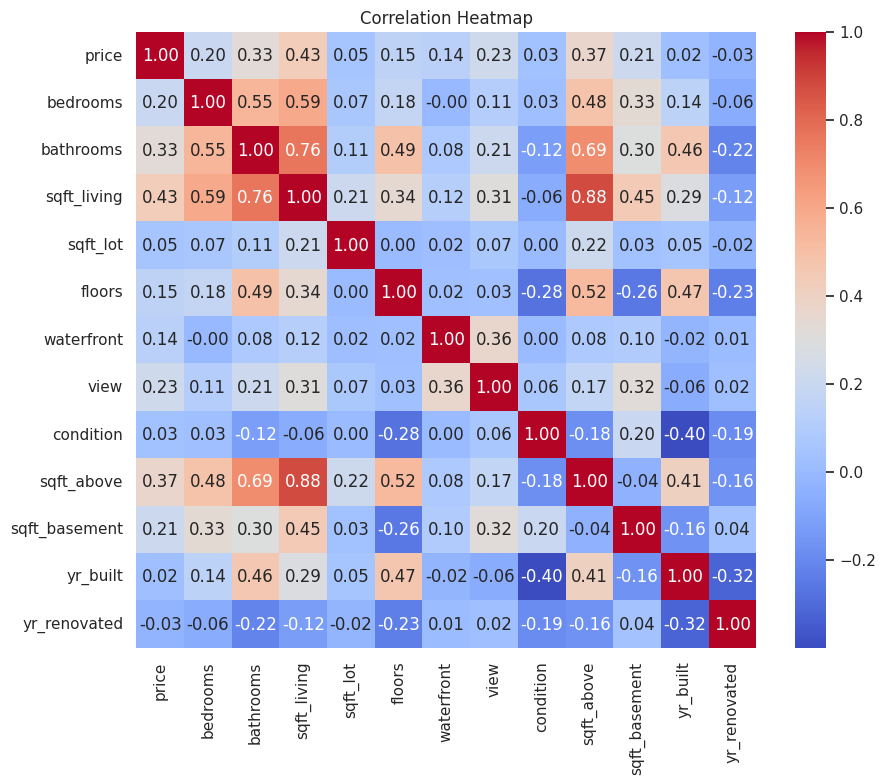

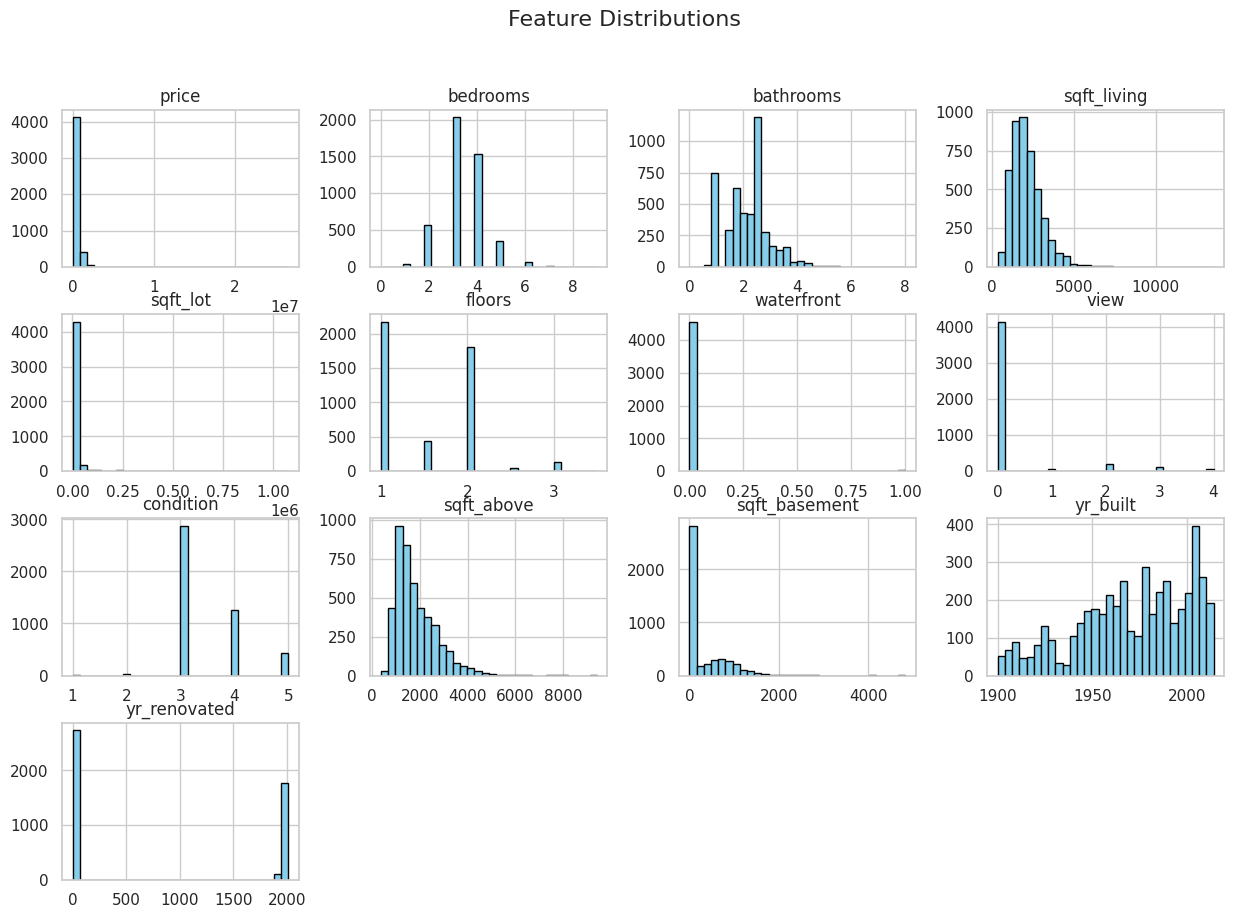

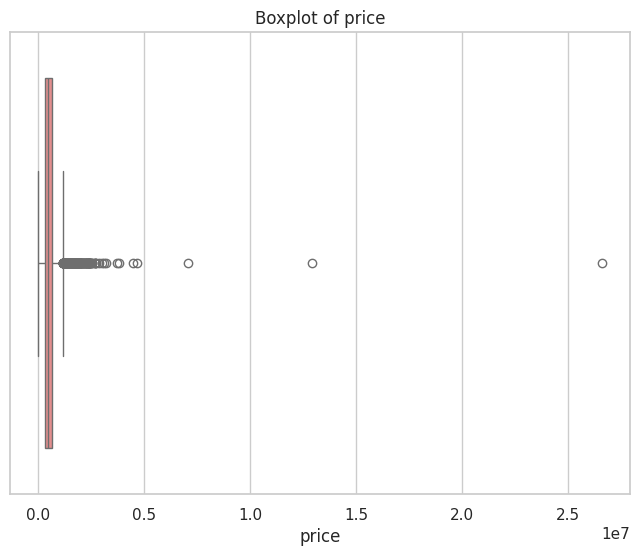

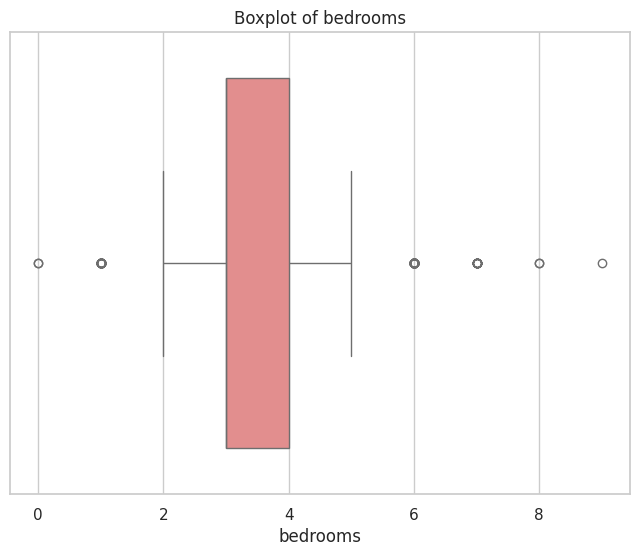

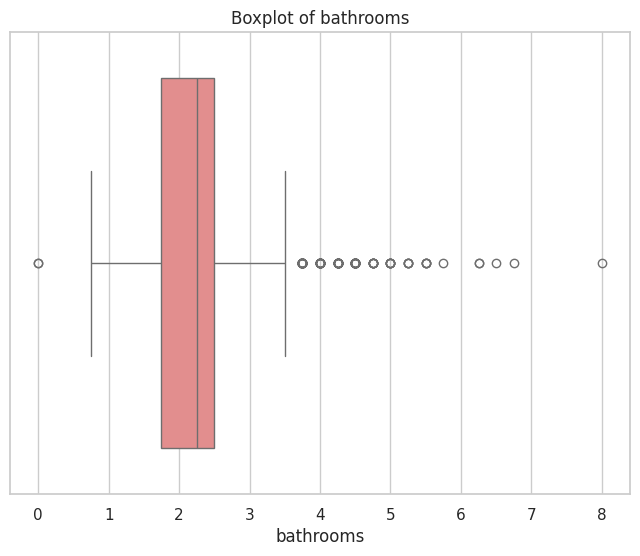

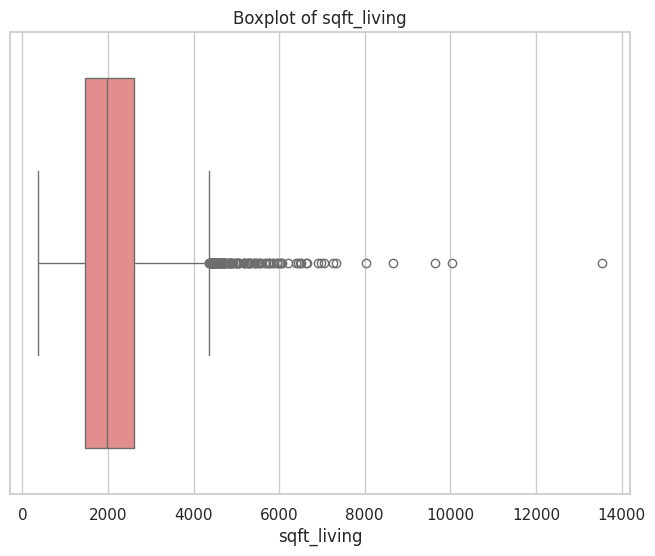

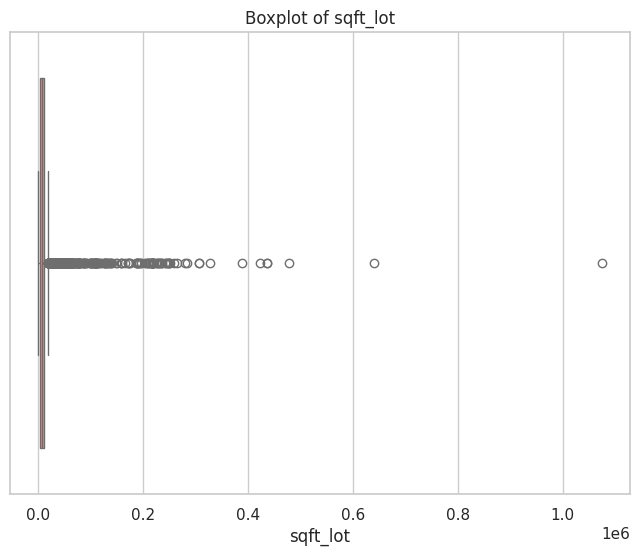

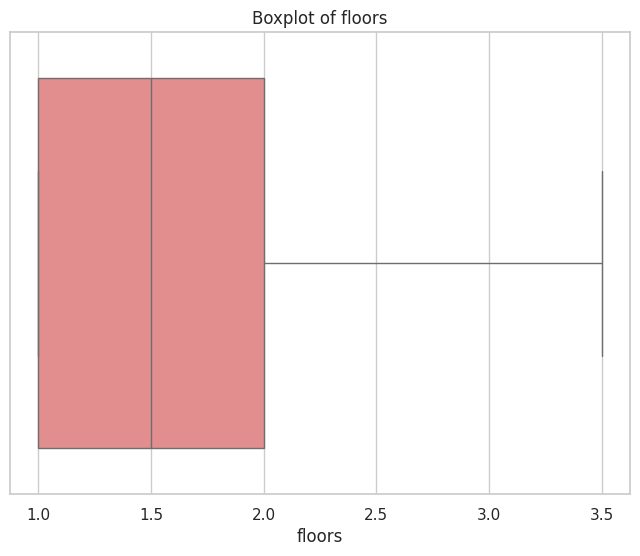

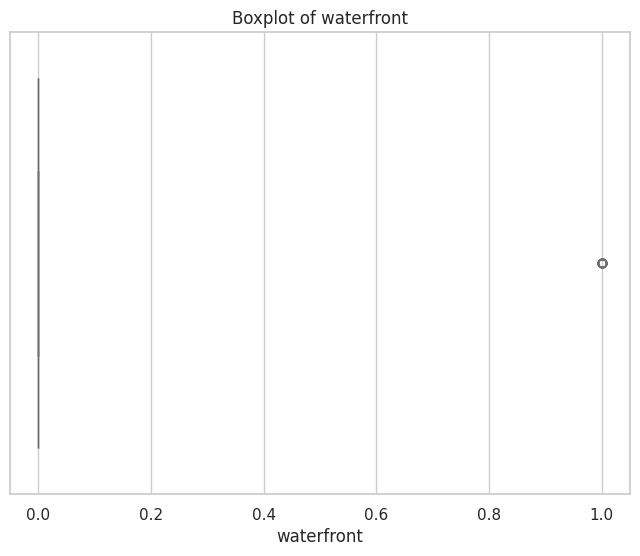

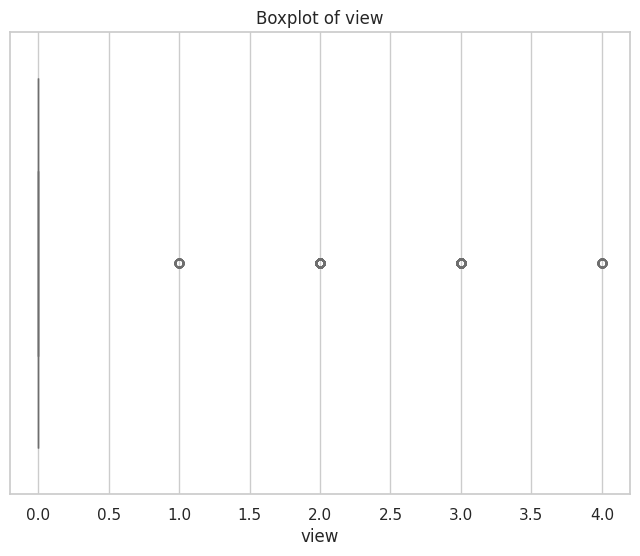

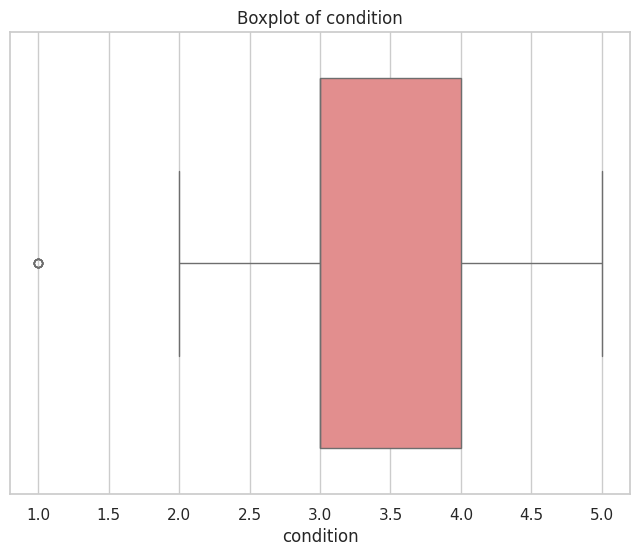

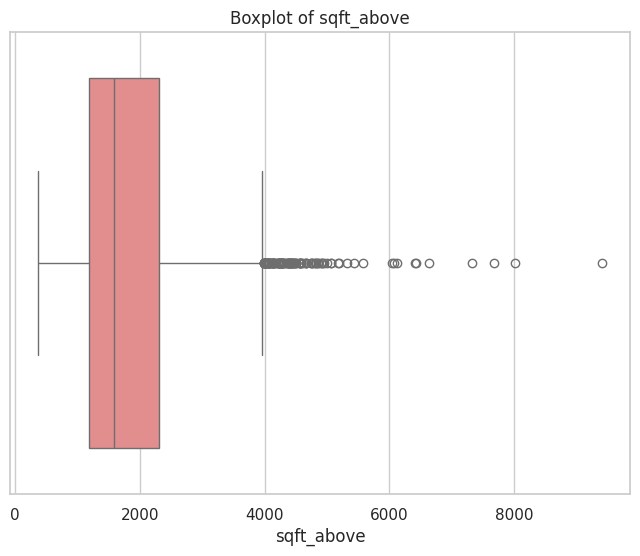

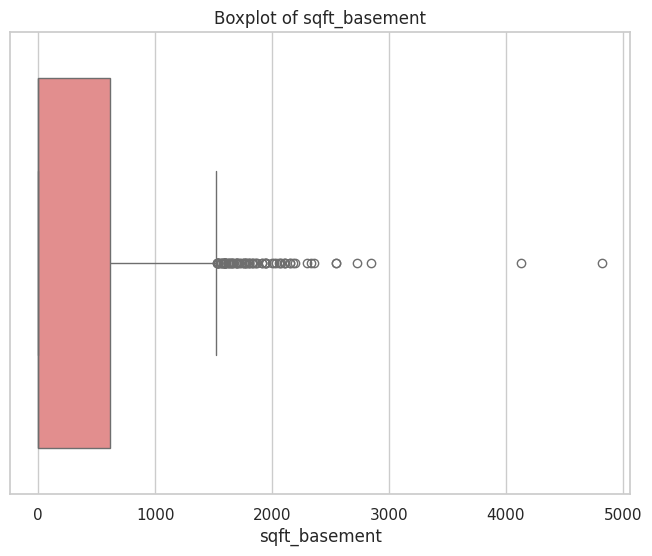

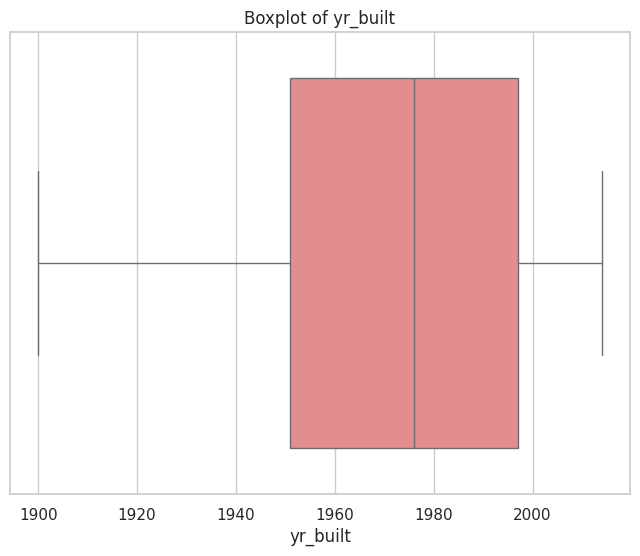

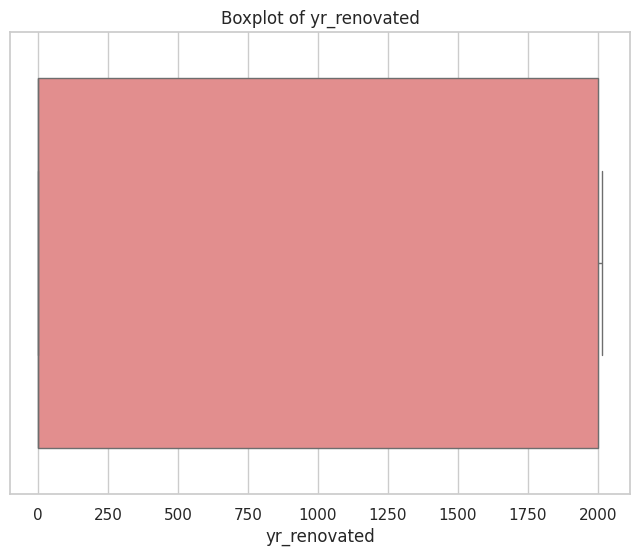

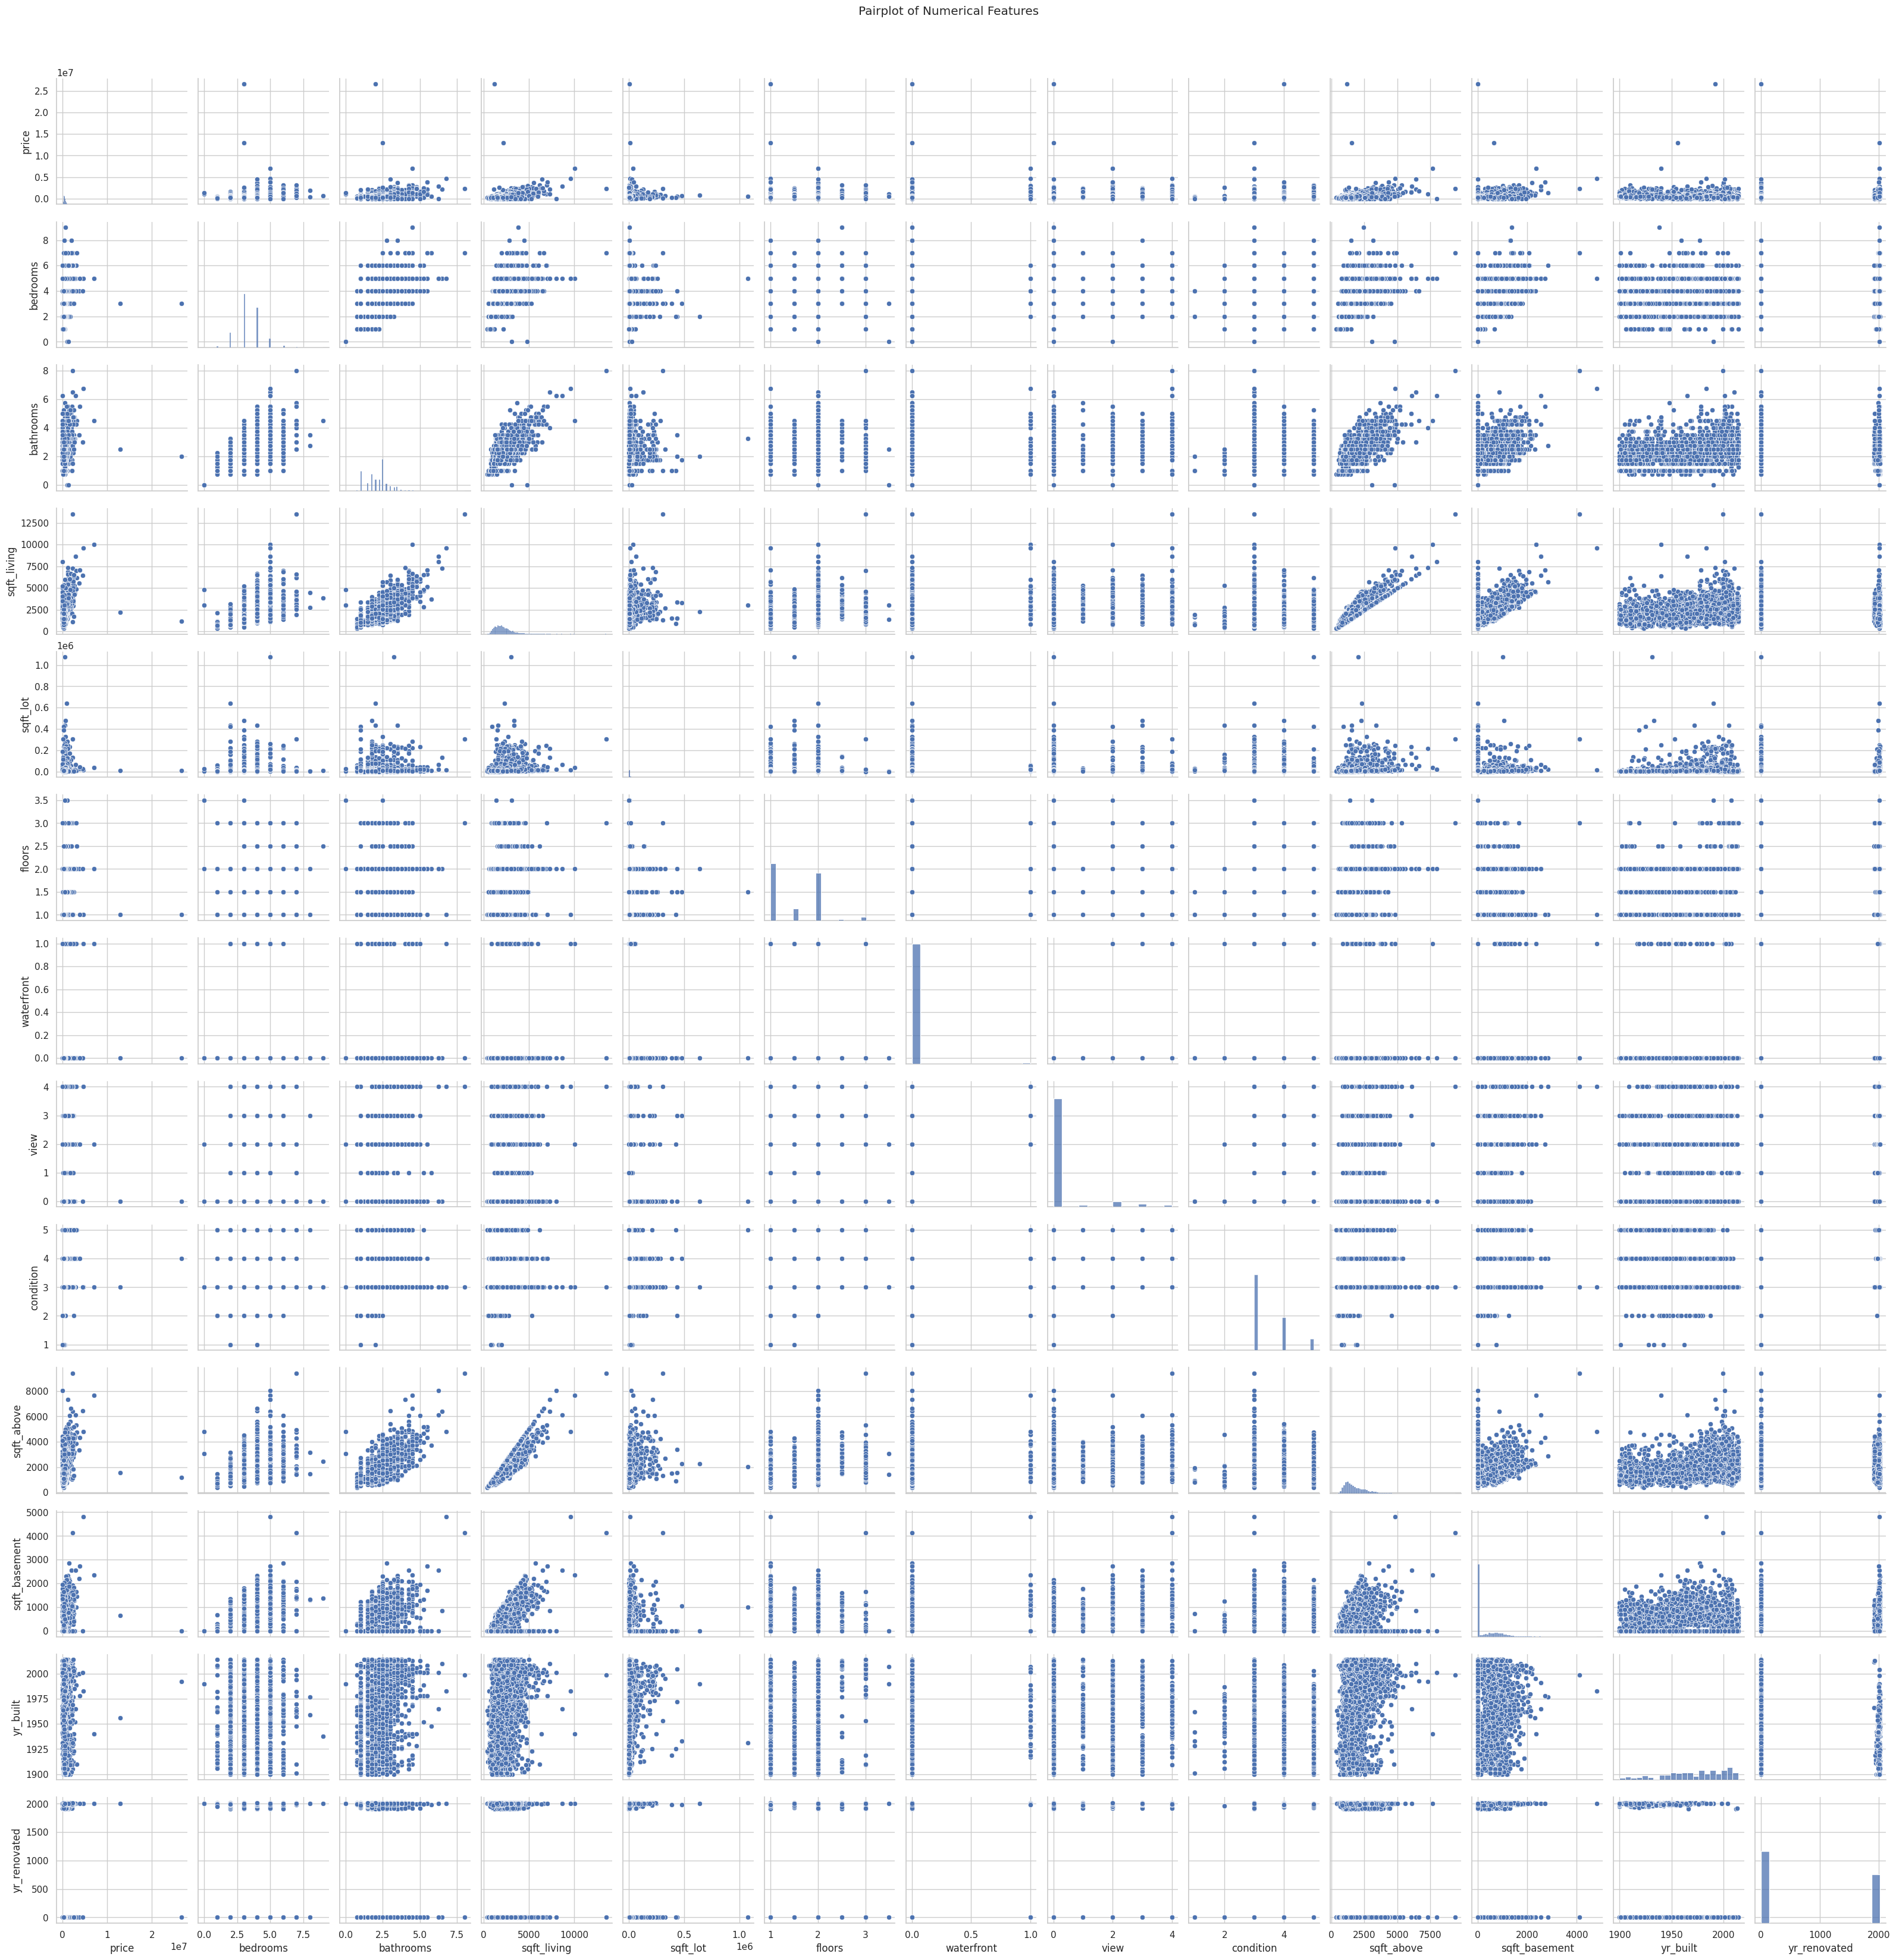

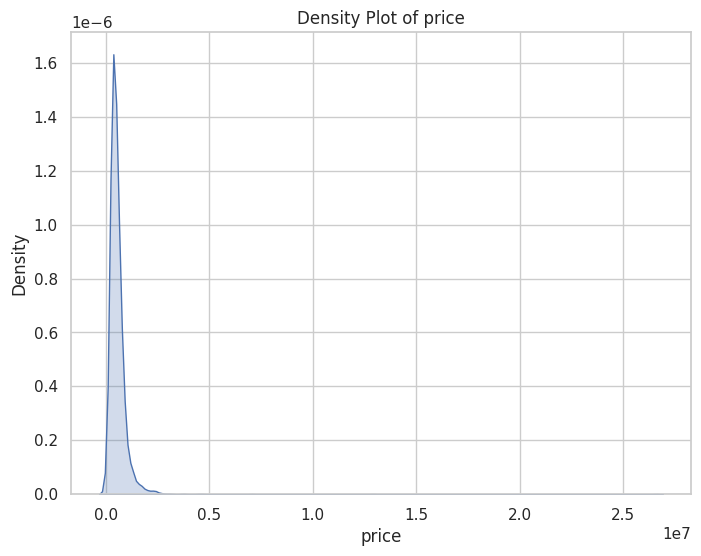

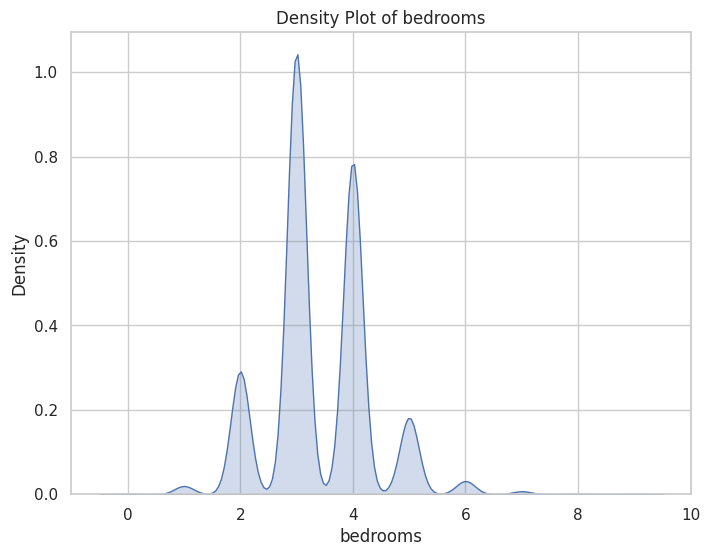

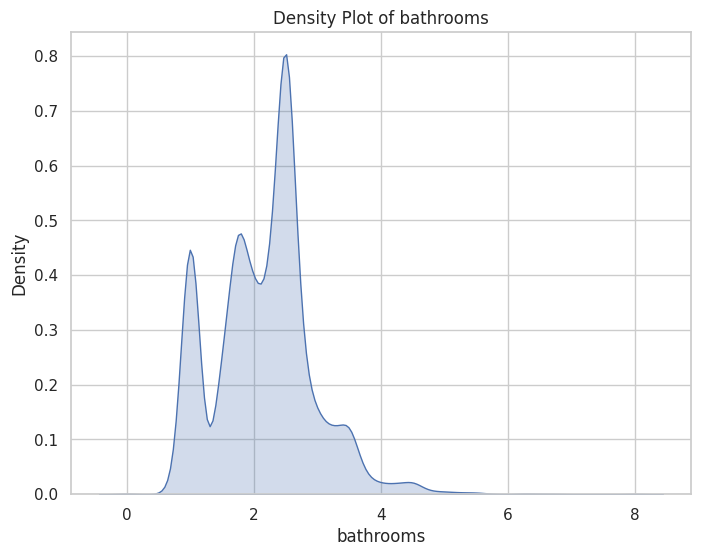

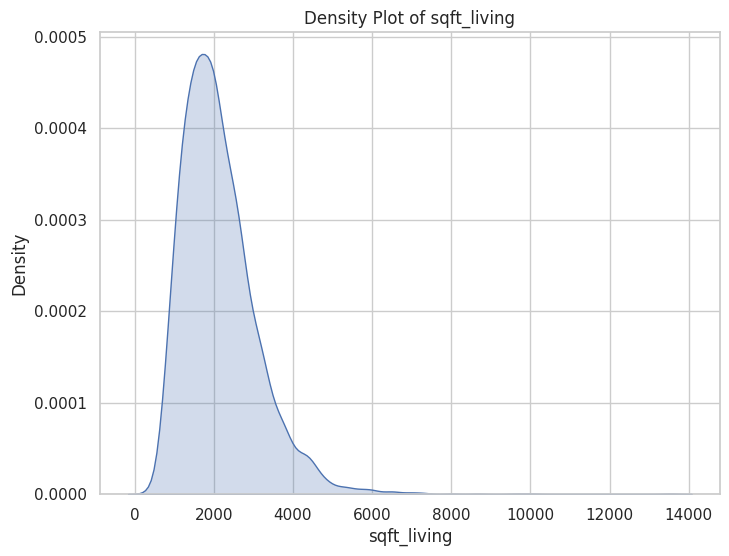

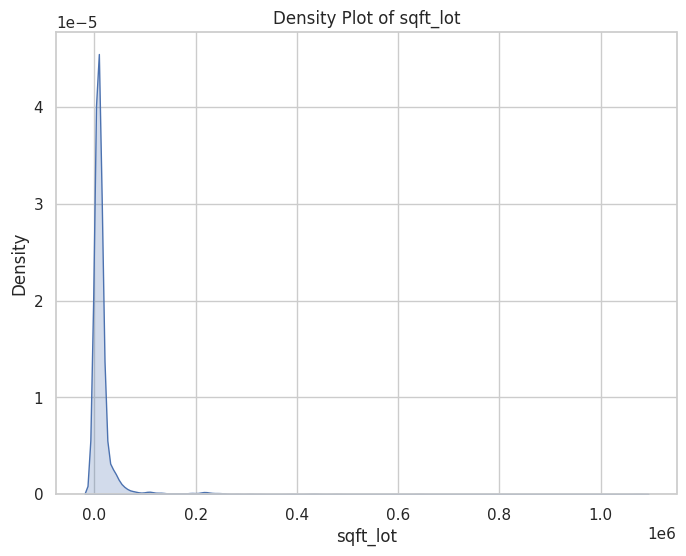

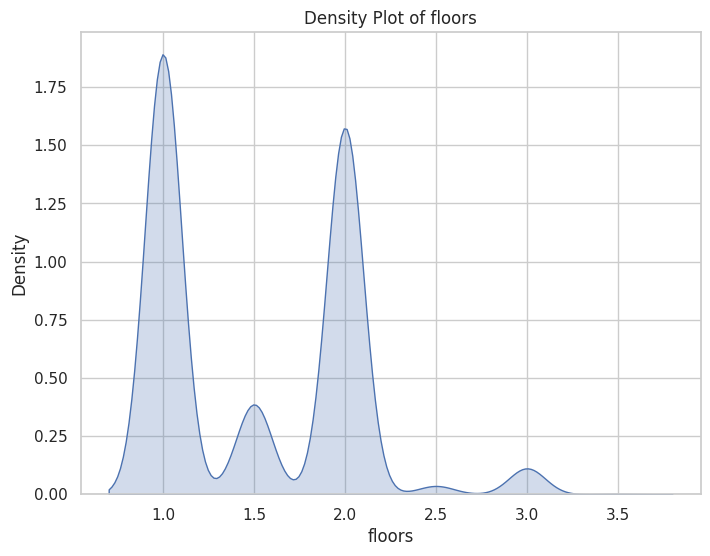

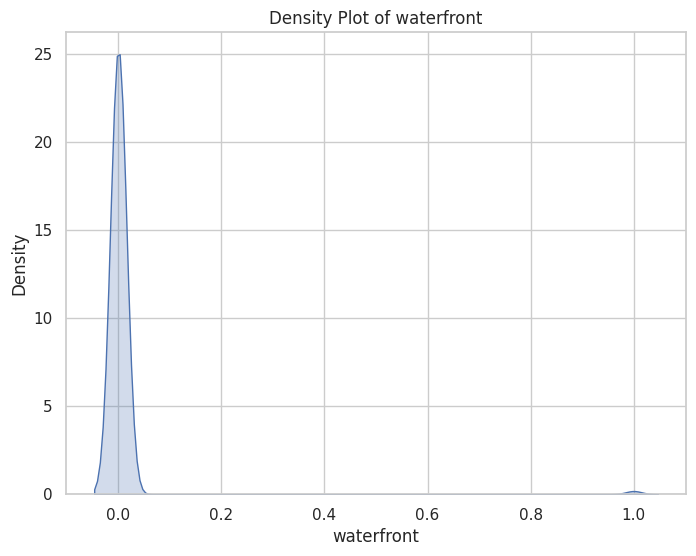

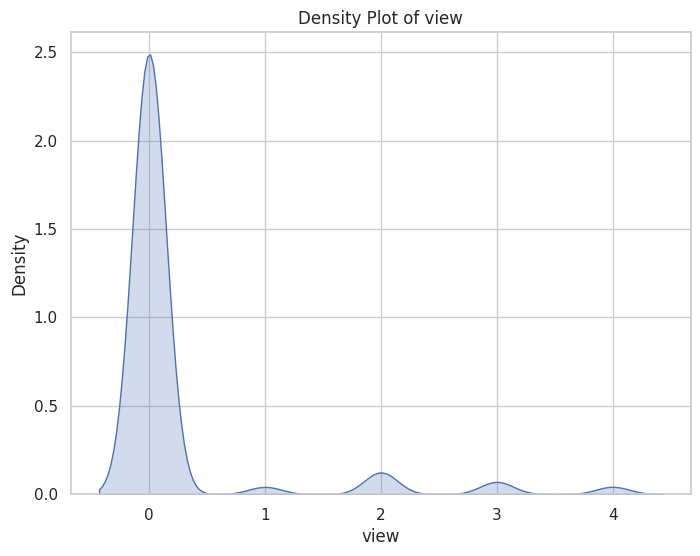

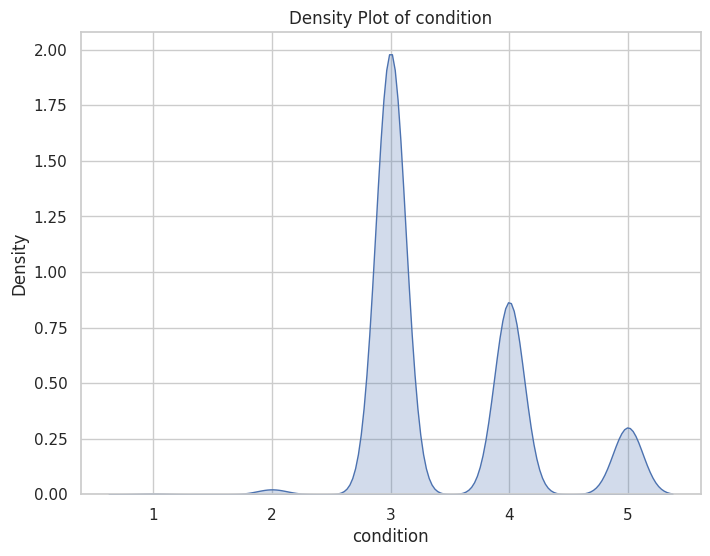

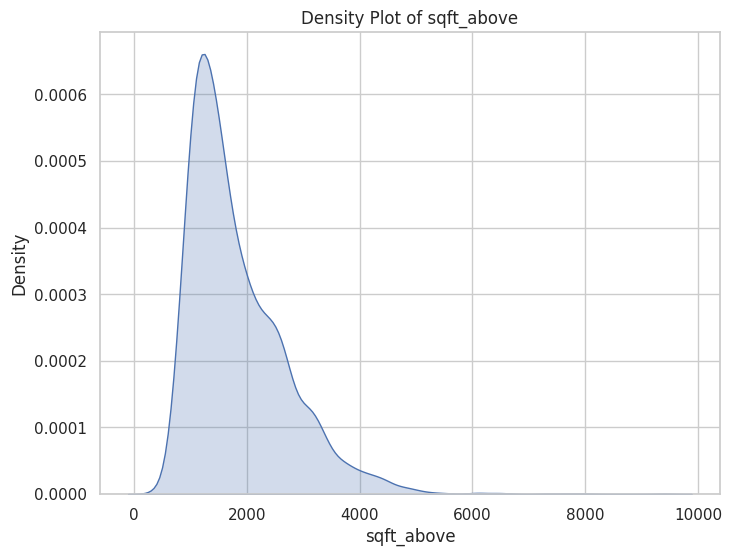

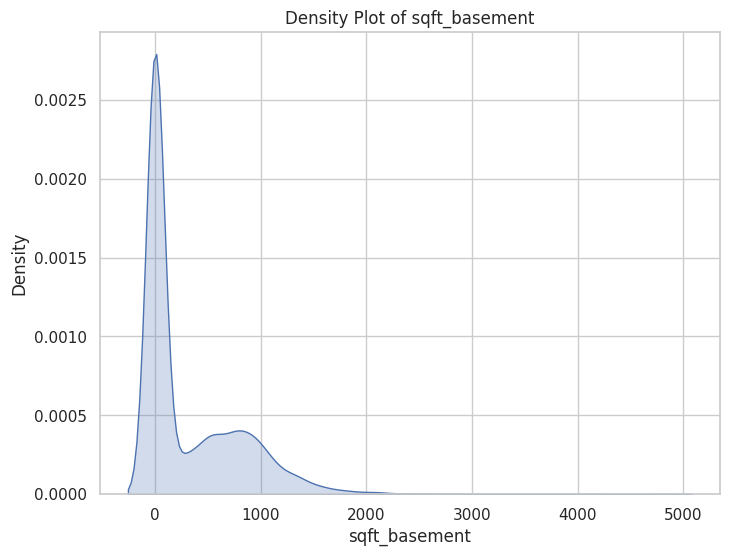

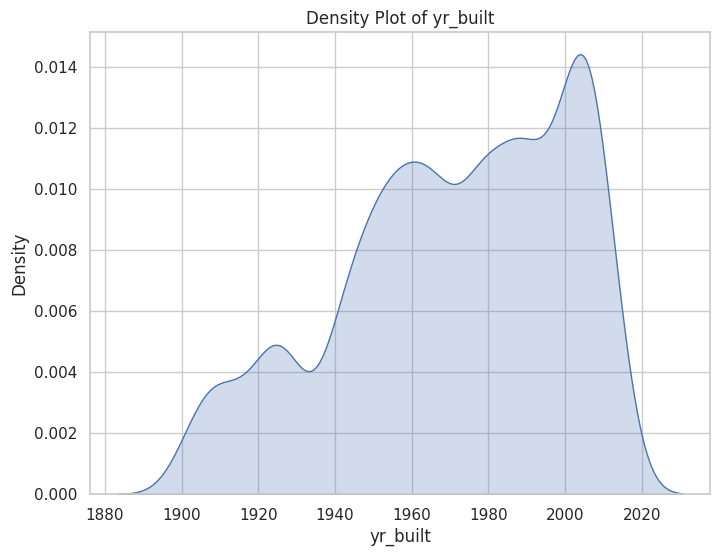

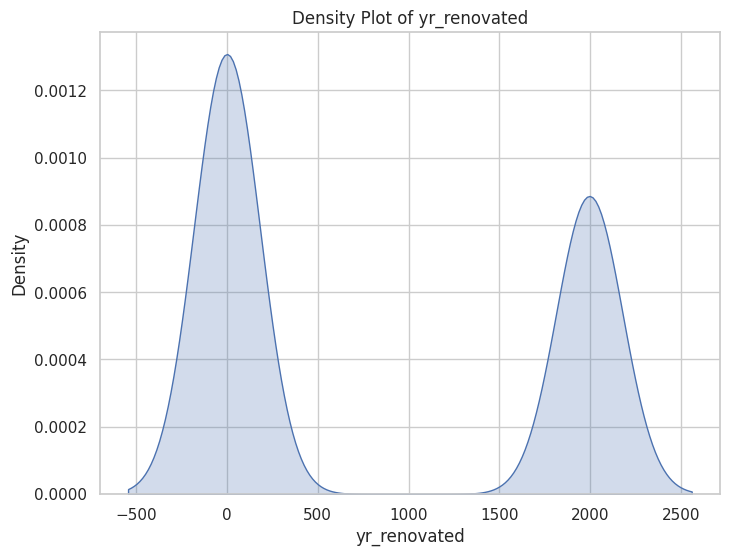

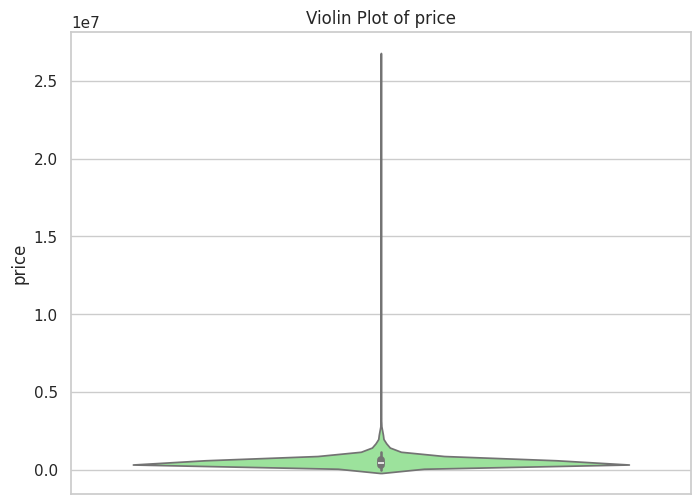

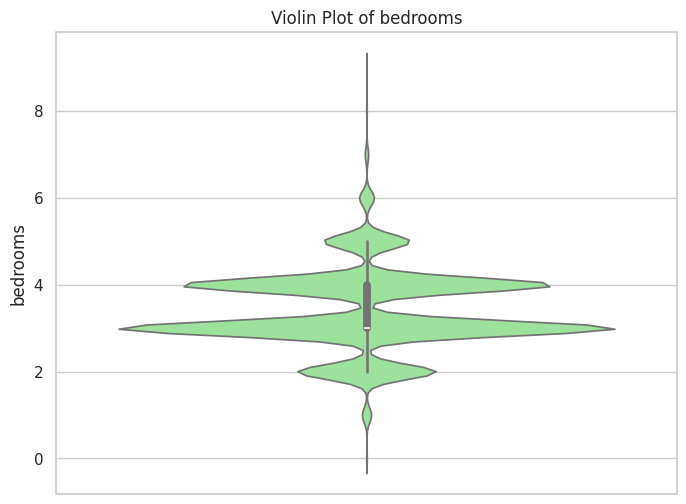

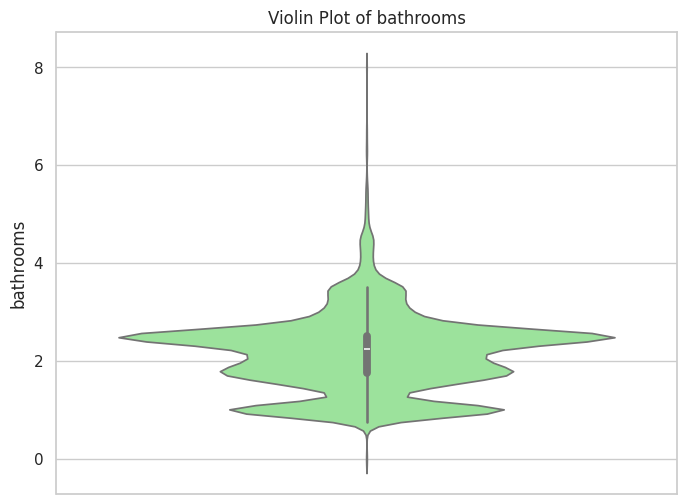

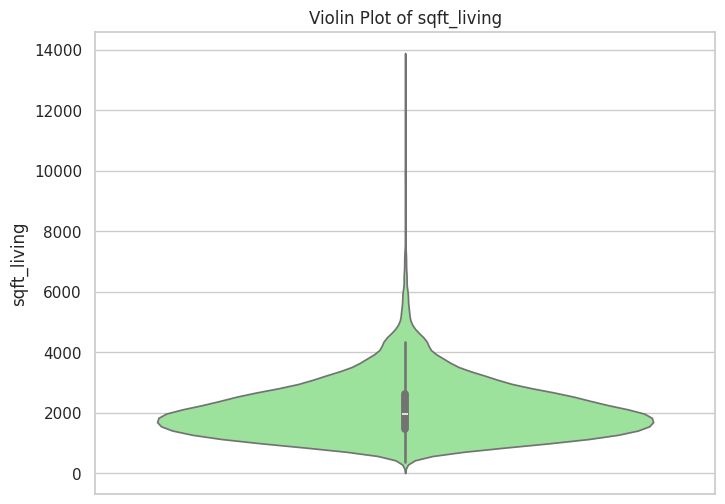

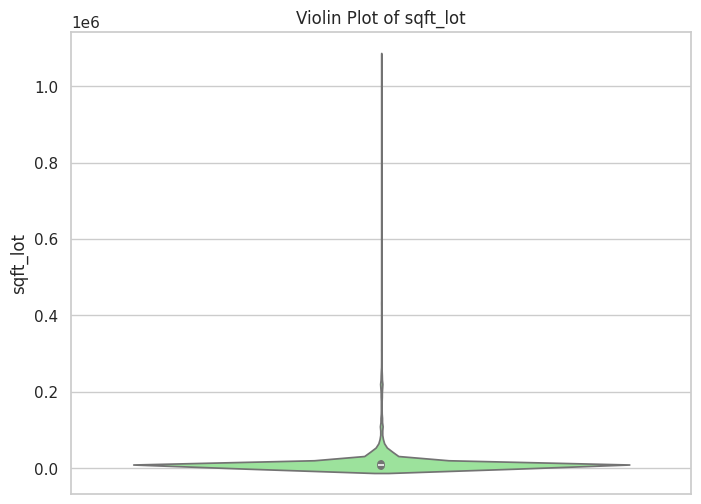

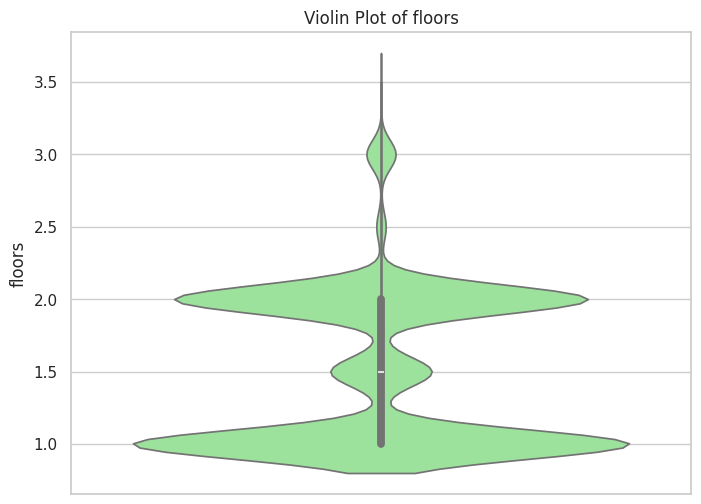

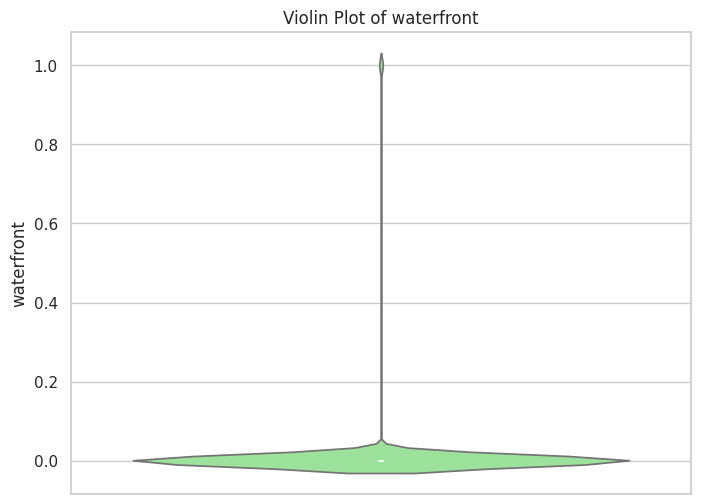

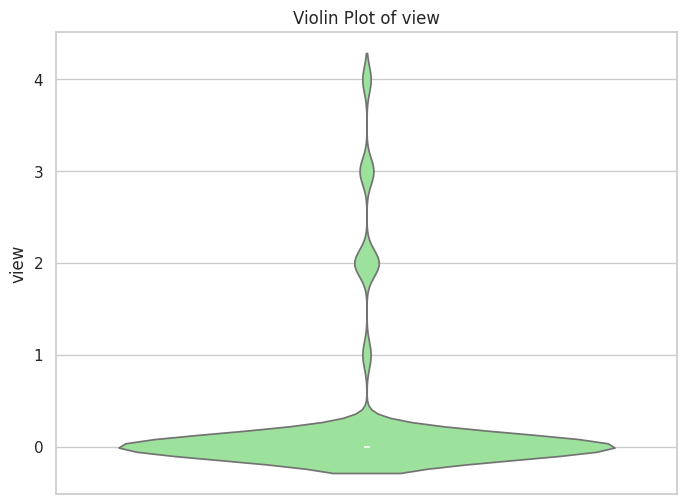

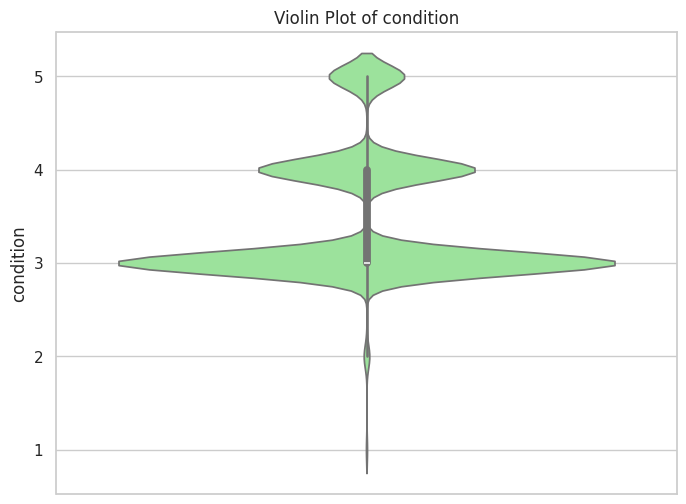

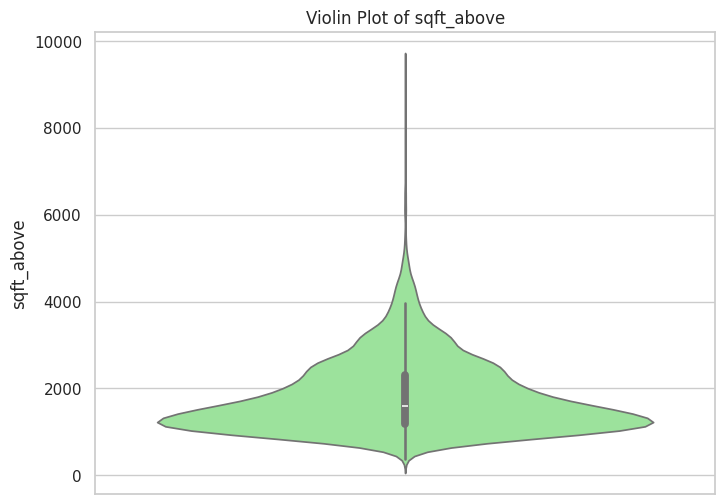

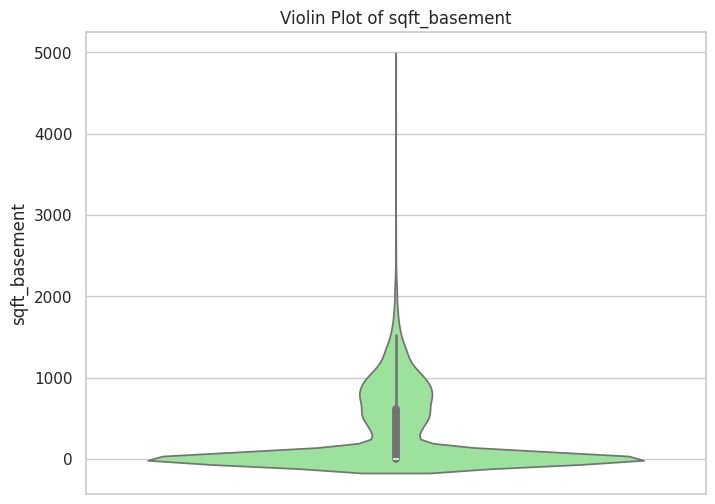

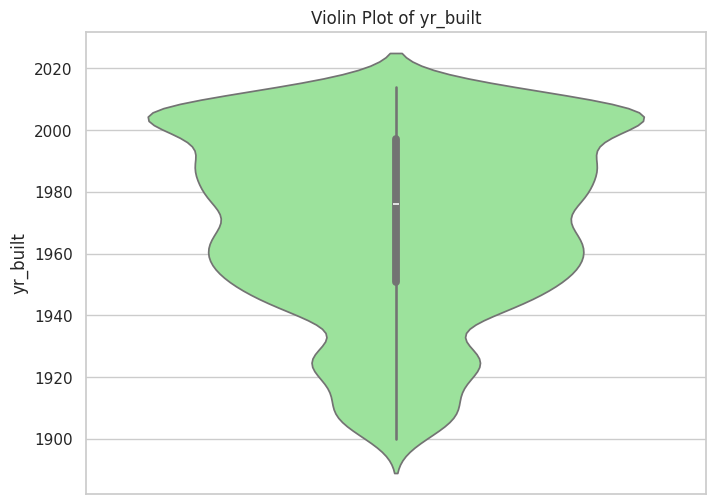

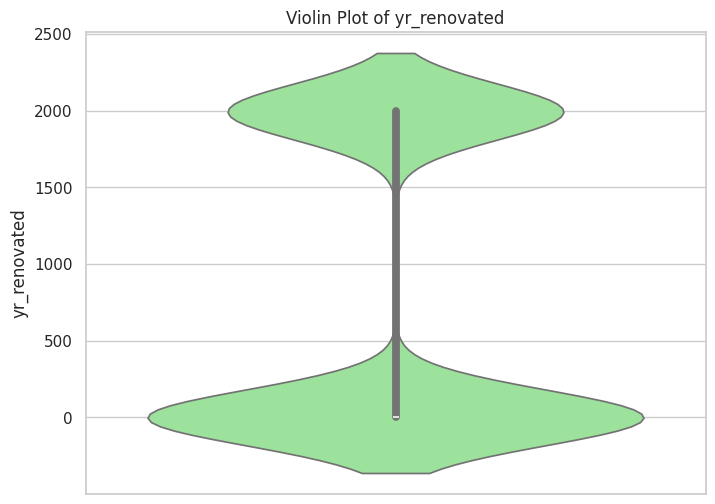

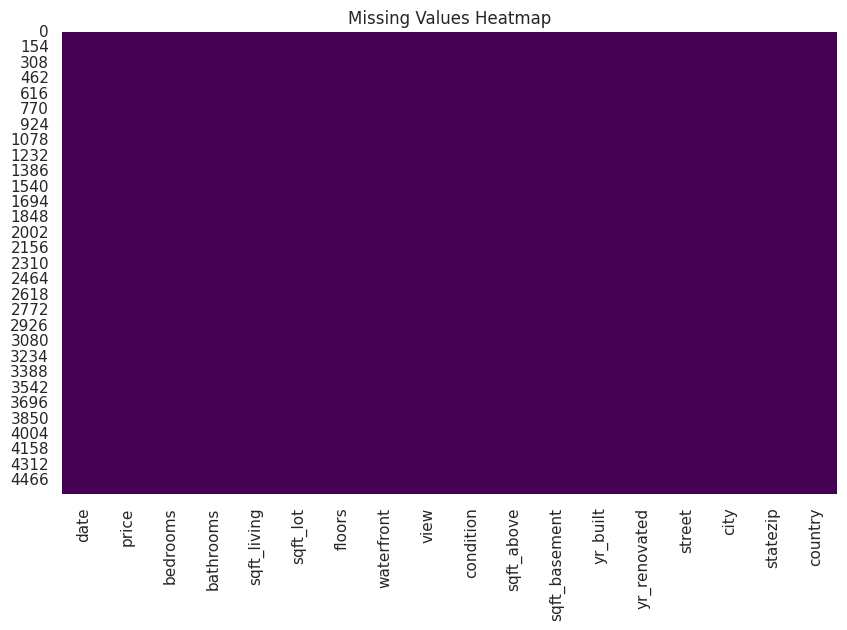

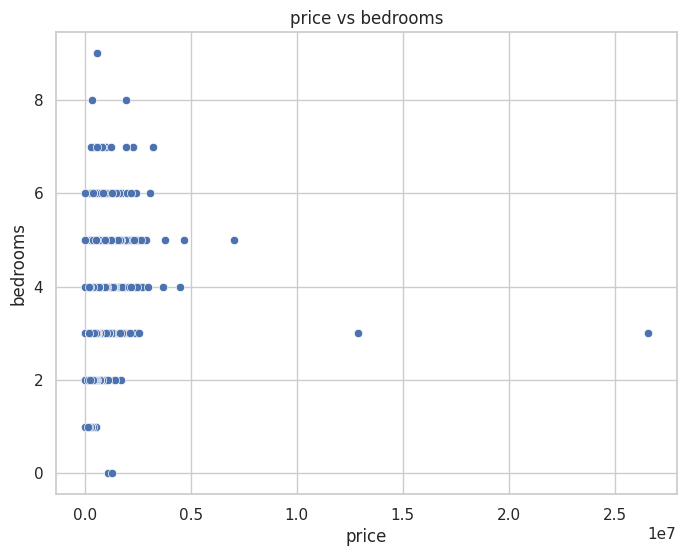

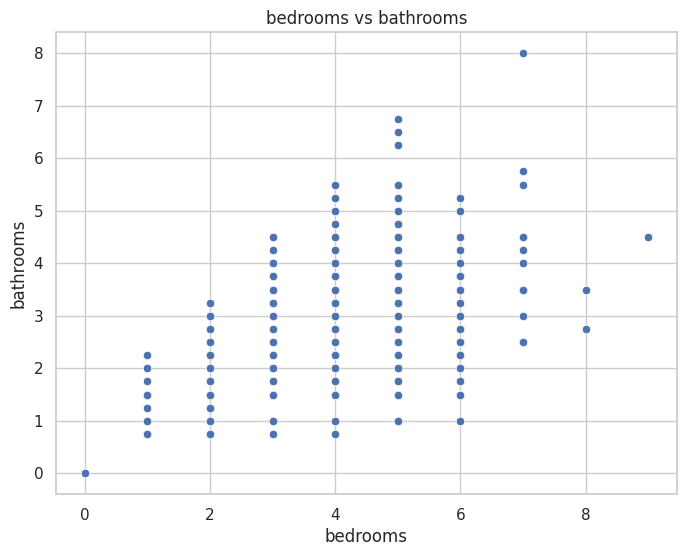

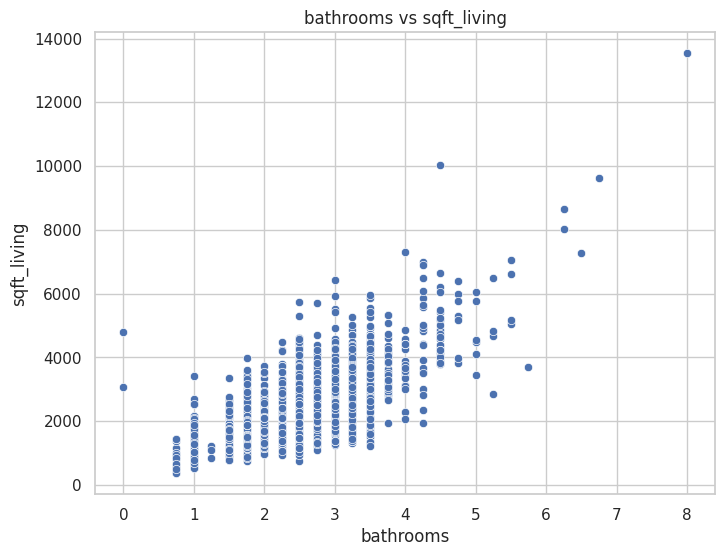

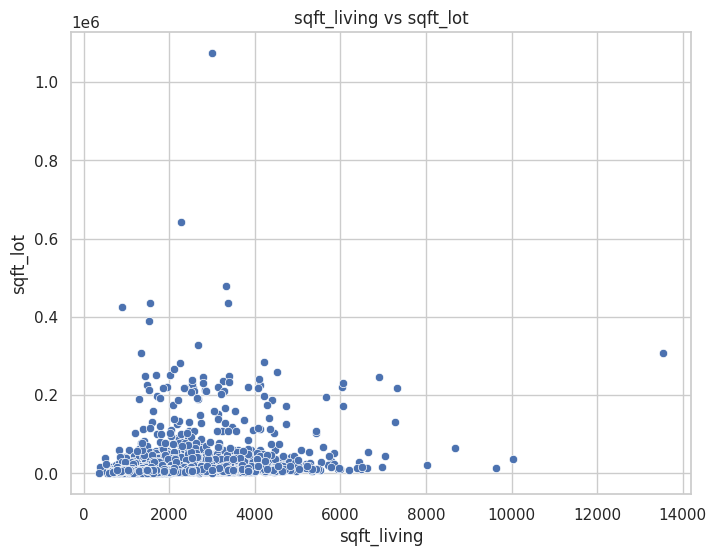

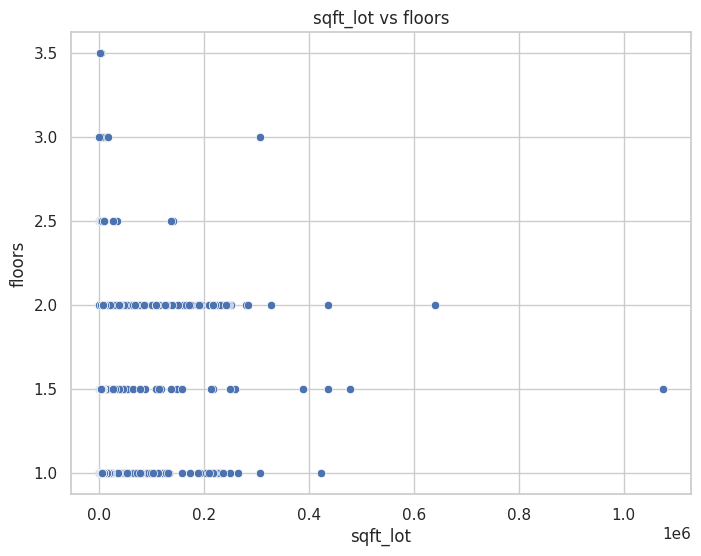

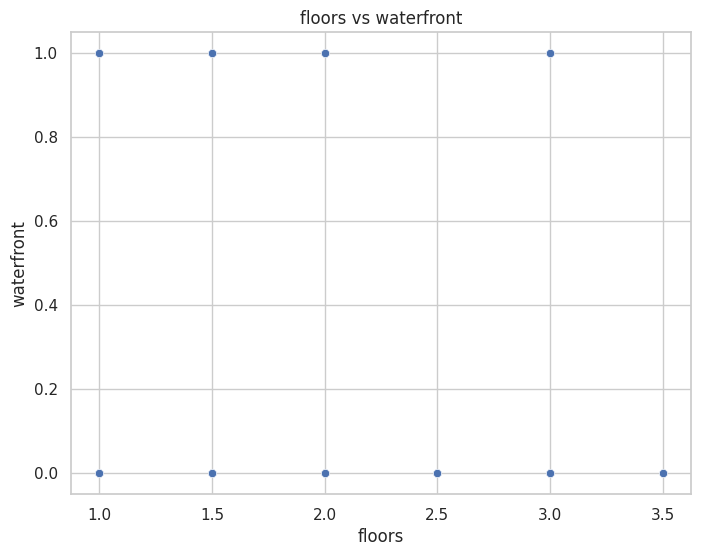

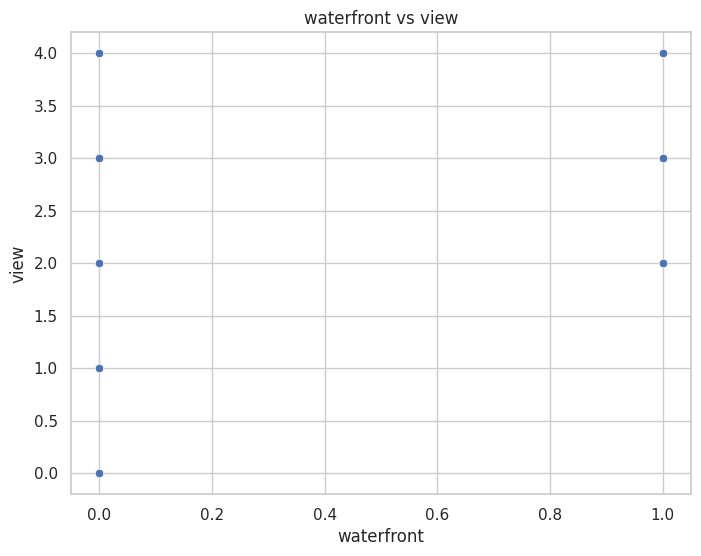

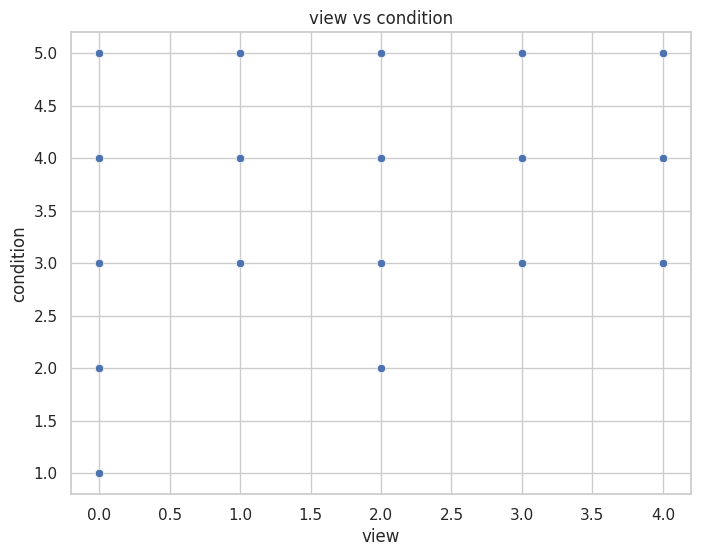

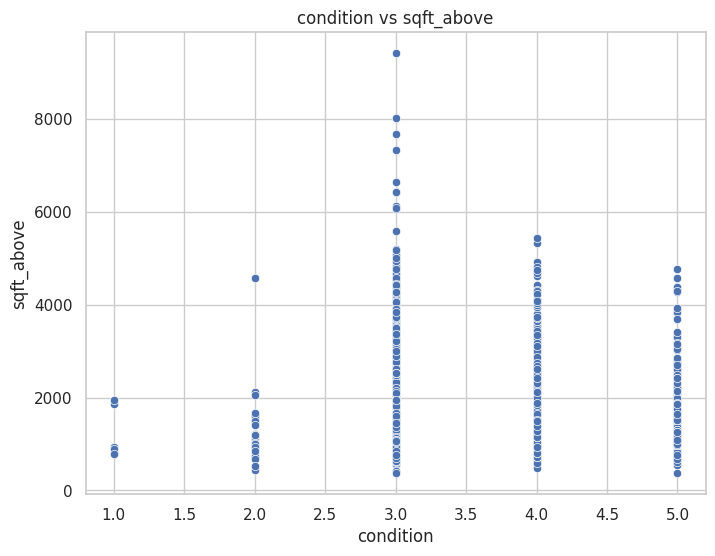

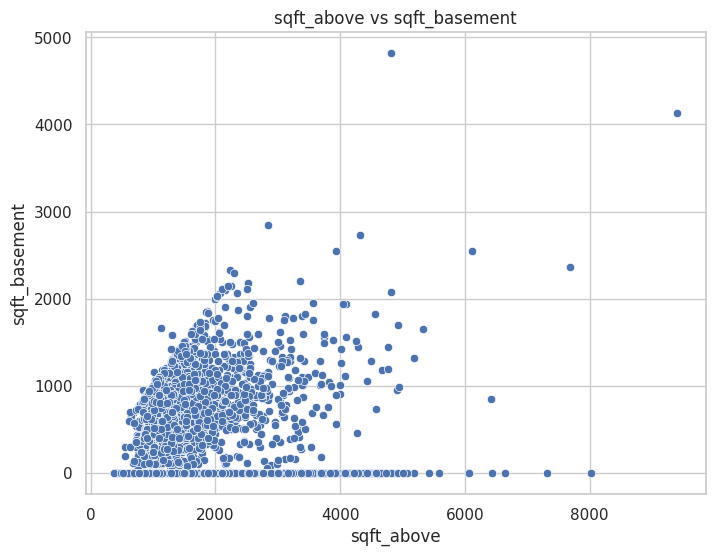

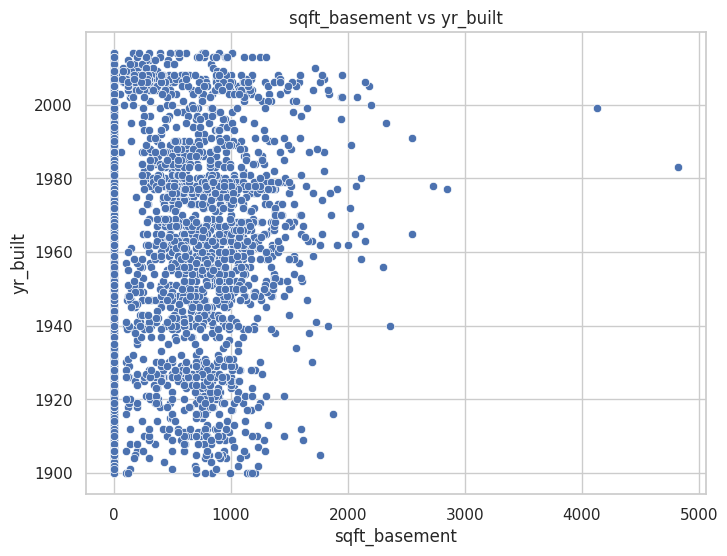

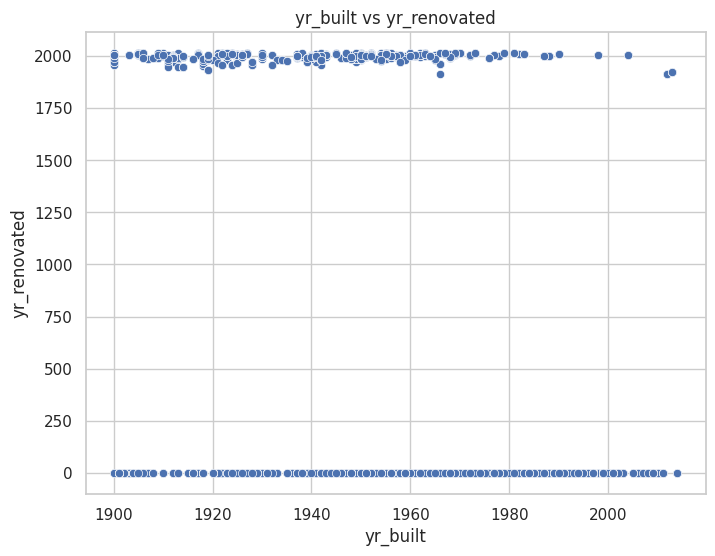

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,6)

# ===============================
# 1. BASIC INFO
# ===============================
print("Shape:", df.shape)
display(df.describe())

# ===============================
# 2. CORRELATION HEATMAP
# ===============================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 3. HISTOGRAMS (ALL NUMERIC)
# ===============================
df.hist(bins=30, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# ===============================
# 4. BOXPLOTS (OUTLIER DETECTION)
# ===============================
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f"Boxplot of {col}")
    plt.show()

# ===============================
# 5. PAIRPLOT (RELATIONSHIPS)
# ===============================
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

# ===============================
# 6. KDE PLOTS (DENSITY)
# ===============================
for col in numeric_cols:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Density Plot of {col}")
    plt.show()

# ===============================
# 7. VIOLIN PLOTS
# ===============================
for col in numeric_cols:
    plt.figure()
    sns.violinplot(y=df[col], color='lightgreen')
    plt.title(f"Violin Plot of {col}")
    plt.show()

# ===============================
# 8. MISSING VALUES VISUALIZATION
# ===============================
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ===============================
# 9. FEATURE VS FEATURE (SCATTER MATRIX STYLE)
# ===============================
if len(numeric_cols) >= 2:
    for i in range(len(numeric_cols)-1):
        plt.figure()
        sns.scatterplot(
            x=df[numeric_cols[i]],
            y=df[numeric_cols[i+1]]
        )
        plt.title(f"{numeric_cols[i]} vs {numeric_cols[i+1]}")
        plt.show()


# Data Cleaning

In [5]:
df = df.fillna(df.median(numeric_only=True))

target = 'price'
X = df.drop(target, axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

# Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Pipeline Model

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())])

# Evaluation

In [8]:
pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print('RMSE:', rmse)
print('R2 Score:', r2)

RMSE: 1070924.3613021902
R2 Score: -0.12456057599100467


# Cross Validation

In [9]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print('CV R2 scores:', scores)
print('Average:', scores.mean())

CV R2 scores: [-50.05915534 -10.573734    -1.15988718  -0.70739324  -0.22400808]
Average: -12.544835566454129


# Save Predictions

In [10]:
submission = pd.DataFrame({'Prediction': pipeline.predict(X)})
submission.to_csv('submission_A.csv', index=False)